Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


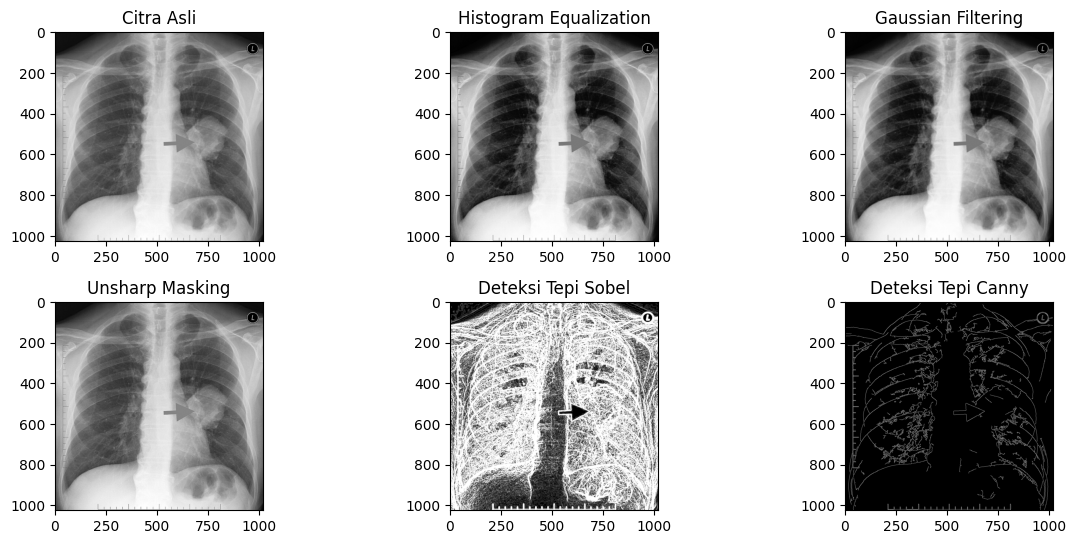

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

img = cv2.imread('/content/drive/MyDrive/SyalmaTarissa2202020018KomputerVision/BAB2/gambar.jpg', cv2.IMREAD_GRAYSCALE)

equ = cv2.equalizeHist(img)

blur = cv2.GaussianBlur(equ, (5, 5), 0)

amount = 1.0
blurred = cv2.GaussianBlur(img, (5, 5), 0)
sharpened = float(amount + 1) * img - float(amount) * blurred
sharpened = np.uint8(np.clip(sharpened, 0, 255))

sobel_x = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=5)
sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_magnitude = np.uint8(np.clip(sobel_magnitude, 0, 255))

canny_edges = cv2.Canny(blur, threshold1=20, threshold2=100)

plt.figure(figsize=(12, 8))

plt.subplot(3, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Citra Asli')

plt.subplot(3, 3, 2)
plt.imshow(equ, cmap='gray')
plt.title('Histogram Equalization')

plt.subplot(3, 3, 3)
plt.imshow(blur, cmap='gray')
plt.title('Gaussian Filtering')

plt.subplot(3, 3, 4)
plt.imshow(sharpened, cmap='gray')
plt.title('Unsharp Masking')

plt.subplot(3, 3, 5)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Deteksi Tepi Sobel')

plt.subplot(3, 3, 6)
plt.imshow(canny_edges, cmap='gray')
plt.title('Deteksi Tepi Canny')

plt.tight_layout()
plt.show()